# Shakespeare

Mensimulasikan data yang dihasilkan oleh sistem sensor ESP32 selama satu hari penuh (07.00 - 17.00). Data dibuat secara sintetis berdasarkan kondisi ruang kelas nyata. Tujuannya adalah untuk memvalidasi logika kontrol sistem sebelum deployment hardware dilakukan.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

## 1. Membuat Timeline dan Data Dummy

Simulasi dimulai pukul 07.00 dan berakhir pukul 17.00 dengan interval pembacaan setiap 1 menit. Total ada 600 titik data yang merepresentasikan satu hari operasional ruang kelas.

In [3]:
# Timeline: 07.00 - 17.00, interval 1 menit
start = datetime(2025, 6, 1, 7, 0, 0)
timestamps = [start + timedelta(minutes=i) for i in range(600)]
t = np.arange(600)

np.random.seed(42)

# Kehadiran (Occupancy)
# Jadwal kelas: 07.00-09.00, 09.30-11.30, 13.00-15.00, istirahat sisanya
occupancy = np.zeros(600)
occupancy[0:120]   = 1   # Kelas 1: 07.00 - 09.00
occupancy[150:270] = 1   # Kelas 2: 09.30 - 11.30
occupancy[360:480] = 1   # Kelas 3: 13.00 - 15.00
# Tambah noise kecil untuk simulasi orang yang keluar masuk
noise_occ = np.random.choice([0, 1], size=600, p=[0.95, 0.05])
occupancy = np.clip(occupancy + noise_occ, 0, 1).astype(int)

# CO2 (ppm)
# Baseline 420 ppm, naik saat kelas penuh, turun perlahan saat kosong
co2 = np.full(600, 420.0)
for i in range(1, 600):
    if occupancy[i] == 1:
        co2[i] = co2[i-1] + np.random.uniform(3, 8)   # naik saat ada orang
    else:
        co2[i] = co2[i-1] - np.random.uniform(2, 5)   # turun saat kosong
    co2[i] = np.clip(co2[i], 400, 1400)
co2 += np.random.normal(0, 5, 600)  # noise sensor

# Suhu (Celsius)
# Pagi 25C, siang naik ke 30C, AC aktif saat ada orang menjaga di 23-26C
base_temp = 25 + 5 * np.sin(np.pi * (t - 60) / 480)  # kurva harian
ac_cooling = occupancy * np.random.uniform(1.5, 3.0, 600)  # efek AC
temperature = base_temp - ac_cooling + np.random.normal(0, 0.3, 600)
temperature = np.clip(temperature, 22, 32)

# Kelembapan (%)
humidity = 60 - 0.05 * t + occupancy * 3 + np.random.normal(0, 1.5, 600)
humidity = np.clip(humidity, 45, 80)

#Cahaya / Lux
# Kurva cahaya matahari: rendah pagi/sore, puncak tengah hari
lux = 80 + 120 * np.sin(np.pi * (t - 30) / 540)
lux += np.random.normal(0, 8, 600)
lux = np.clip(lux, 5, 220)

# Duty Cycle Lampu PWM (0-255)
LUX_GELAP  = 20
LUX_TERANG = 150
duty = np.where(
    lux <= LUX_GELAP,  255,
    np.where(
        lux >= LUX_TERANG, 0,
        255 - ((lux - LUX_GELAP) / (LUX_TERANG - LUX_GELAP) * 255)
    )
).astype(int)
# Lampu hanya menyala saat ada orang
duty = duty * occupancy

# Data Energi Listrik (PZEM-004T)
voltage   = 220 + np.random.normal(0, 1.5, 600)
current   = occupancy * np.random.uniform(3.5, 5.5, 600) + 0.5  # AC + beban dasar
power     = voltage * current
frequency = 50 + np.random.normal(0, 0.1, 600)
pf        = 0.85 + np.random.normal(0, 0.02, 600)
pf        = np.clip(pf, 0.80, 0.95)

# Akumulasi energi kWh (integrasi daya per menit)
energy_kwh = np.cumsum(power / 60000)  # watt-menit ke kWh

# Gabungkan ke DataFrame
df = pd.DataFrame({
    'timestamp'  : timestamps,
    'occupancy'  : occupancy,
    'co2_ppm'    : co2.round(1),
    'temperature': temperature.round(2),
    'humidity'   : humidity.round(1),
    'lux'        : lux.round(1),
    'lamp_duty'  : duty,
    'voltage_v'  : voltage.round(1),
    'current_a'  : current.round(3),
    'power_w'    : power.round(1),
    'frequency_hz': frequency.round(2),
    'power_factor': pf.round(3),
    'energy_kwh' : energy_kwh.round(4)
})

df.set_index('timestamp', inplace=True)
print(f"Total data: {len(df)} baris")
df.head(10)

Total data: 600 baris


,occupancy,co2_ppm,temperature,humidity,lux,lamp_duty,voltage_v,current_a,power_w,frequency_hz,power_factor,energy_kwh
timestamp,,,,,,,,,,,,
2025-06-01 07:00:00,1,421.8,22.0,65.1,72.1,152,220.2,5.051,1112.4,50.12,0.800,0.0185
2025-06-01 07:01:00,1,421.2,22.0,63.6,67.2,162,218.2,4.132,901.7,50.06,0.824,0.0336
2025-06-01 07:02:00,1,427.6,22.0,64.0,46.8,202,219.7,5.945,1306.0,50.02,0.862,0.0553
2025-06-01 07:03:00,1,421.9,22.0,63.8,75.8,145,218.9,4.720,1033.2,50.04,0.807,0.0726
2025-06-01 07:04:00,1,439.2,22.0,61.1,69.3,158,219.2,4.956,1086.5,49.95,0.874,0.0907
2025-06-01 07:05:00,1,444.6,22.0,62.8,56.5,183,219.9,4.711,1035.7,49.94,0.871,0.1079
2025-06-01 07:06:00,1,436.0,22.0,64.3,69.1,158,219.8,5.365,1179.2,49.96,0.851,0.1276
2025-06-01 07:07:00,1,446.5,22.0,64.9,55.7,184,220.6,5.324,1174.7,50.05,0.862,0.1472
2025-06-01 07:08:00,1,447.2,22.0,61.5,69.6,157,220.8,5.431,1199.3,50.02,0.861,0.1671


## 2. Statistik Ringkas

In [4]:
print(" Statistik Harian")
print(f"Durasi kelas terisi   : {occupancy.sum()} menit ({occupancy.sum()/60:.1f} jam)")
print(f"CO2 rata-rata         : {co2.mean():.1f} ppm")
print(f"CO2 maksimum          : {co2.max():.1f} ppm")
print(f"Suhu rata-rata        : {temperature.mean():.1f} C")
print(f"Lux rata-rata         : {lux.mean():.1f} lux")
print(f"Total konsumsi energi : {energy_kwh[-1]:.3f} kWh")
print(f"Daya rata-rata        : {power.mean():.1f} W")

=== Statistik Harian ===
Durasi kelas terisi   : 374 menit (6.2 jam)
CO2 rata-rata         : 1150.4 ppm
CO2 maksimum          : 1411.6 ppm
Suhu rata-rata        : 26.0 C
Lux rata-rata         : 147.7 lux
Total konsumsi energi : 7.289 kWh
Daya rata-rata        : 728.9 W


## 3. Visualisasi CO2 dan Status Kehadiran


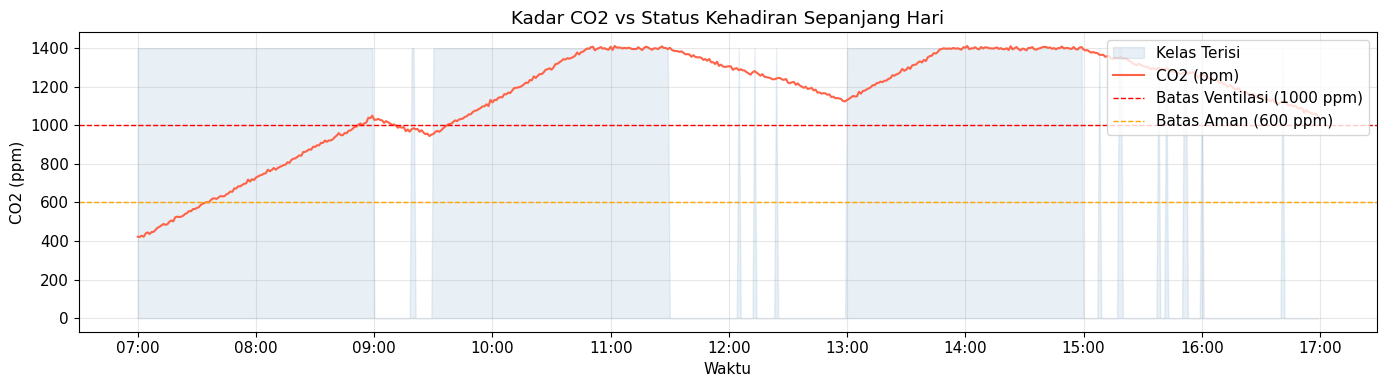

In [5]:
fig, ax1 = plt.subplots()

ax1.fill_between(df.index, occupancy * 1400, alpha=0.12, color='steelblue', label='Kelas Terisi')
ax1.plot(df.index, df['co2_ppm'], color='tomato', linewidth=1.5, label='CO2 (ppm)')
ax1.axhline(1000, color='red', linestyle='--', linewidth=1, label='Batas Ventilasi (1000 ppm)')
ax1.axhline(600,  color='orange', linestyle='--', linewidth=1, label='Batas Aman (600 ppm)')

ax1.set_ylabel('CO2 (ppm)')
ax1.set_xlabel('Waktu')
ax1.set_title('Kadar CO2 vs Status Kehadiran Sepanjang Hari')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. Visualisasi Cahaya (Lux) vs Duty Cycle Lampu

Bagaimana sistem mengatur kecerahan lampu secara proporsional terhadap cahaya alami yang masuk.

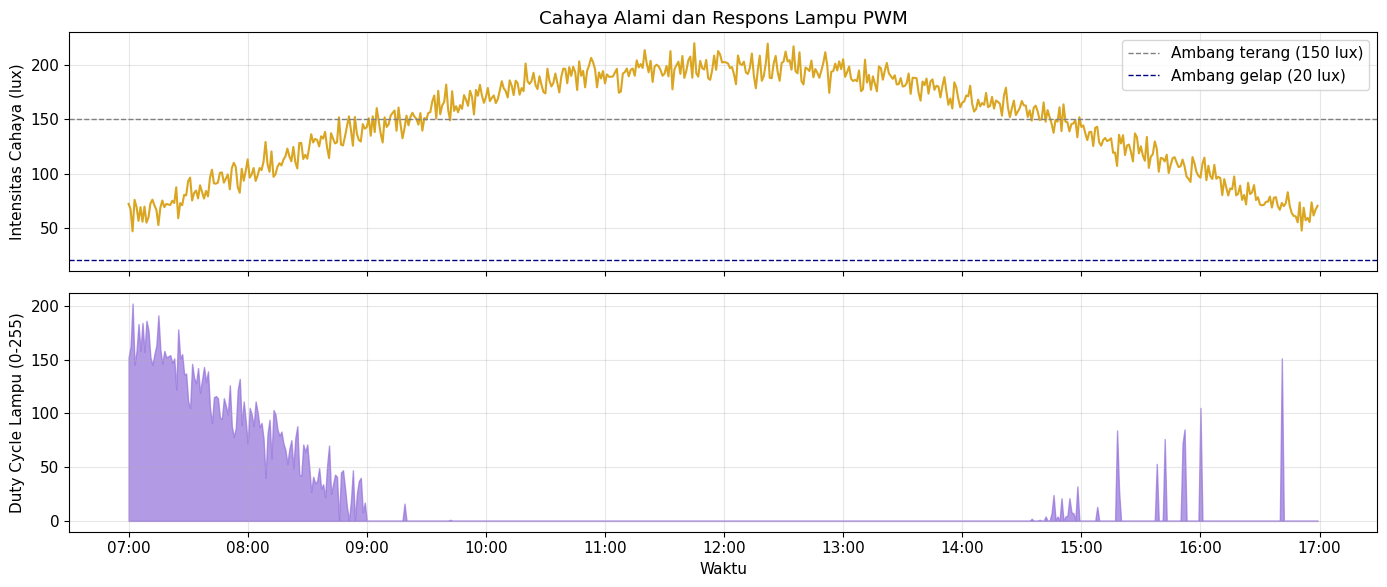

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6))

ax1.plot(df.index, df['lux'], color='goldenrod', linewidth=1.5)
ax1.axhline(LUX_TERANG, color='gray', linestyle='--', linewidth=1, label=f'Ambang terang ({LUX_TERANG} lux)')
ax1.axhline(LUX_GELAP,  color='navy', linestyle='--', linewidth=1, label=f'Ambang gelap ({LUX_GELAP} lux)')
ax1.set_ylabel('Intensitas Cahaya (lux)')
ax1.set_title('Cahaya Alami dan Respons Lampu PWM')
ax1.legend()

ax2.fill_between(df.index, df['lamp_duty'], alpha=0.7, color='mediumpurple')
ax2.set_ylabel('Duty Cycle Lampu (0-255)')
ax2.set_xlabel('Waktu')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

## 5. Visualisasi Suhu dan Kelembapan

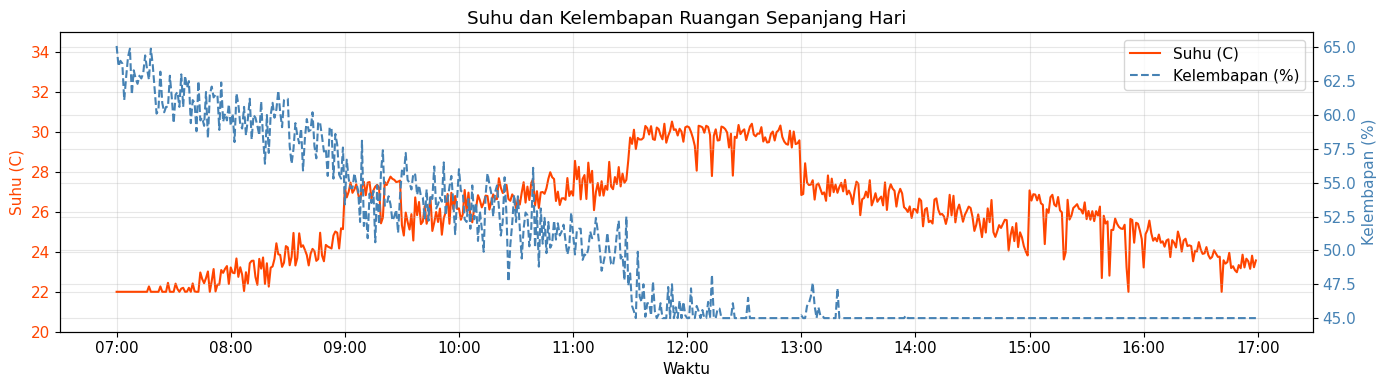

In [7]:
fig, ax1 = plt.subplots()

color_temp = 'orangered'
color_hum  = 'steelblue'

ax1.plot(df.index, df['temperature'], color=color_temp, linewidth=1.5, label='Suhu (C)')
ax1.set_ylabel('Suhu (C)', color=color_temp)
ax1.tick_params(axis='y', labelcolor=color_temp)
ax1.set_ylim(20, 35)

ax2 = ax1.twinx()
ax2.plot(df.index, df['humidity'], color=color_hum, linewidth=1.5, linestyle='--', label='Kelembapan (%)')
ax2.set_ylabel('Kelembapan (%)', color=color_hum)
ax2.tick_params(axis='y', labelcolor=color_hum)

ax1.set_title('Suhu dan Kelembapan Ruangan Sepanjang Hari')
ax1.set_xlabel('Waktu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## 6. Visualisasi Konsumsi Daya dan Akumulasi Energi (PZEM-004T)

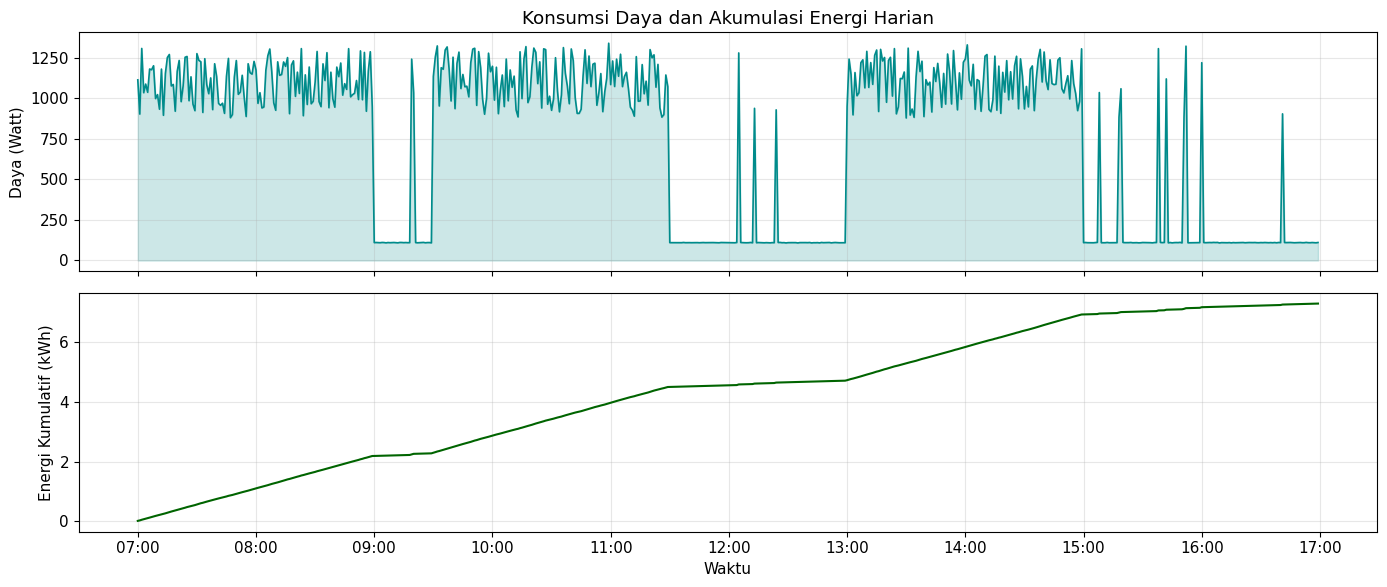

Total energi terpakai hari ini: 7.289 kWh
Estimasi biaya (Rp 1.500/kWh) : Rp 10,934


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 6))

ax1.plot(df.index, df['power_w'], color='darkcyan', linewidth=1.2)
ax1.fill_between(df.index, df['power_w'], alpha=0.2, color='darkcyan')
ax1.set_ylabel('Daya (Watt)')
ax1.set_title('Konsumsi Daya dan Akumulasi Energi Harian')

ax2.plot(df.index, df['energy_kwh'], color='darkgreen', linewidth=1.5)
ax2.set_ylabel('Energi Kumulatif (kWh)')
ax2.set_xlabel('Waktu')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

print(f"Total energi terpakai hari ini: {df['energy_kwh'].iloc[-1]:.3f} kWh")
print(f"Estimasi biaya (Rp 1.500/kWh) : Rp {df['energy_kwh'].iloc[-1] * 1500:,.0f}")

## 7. Simulasi Potensi Penghematan Energi

Bagian ini membandingkan konsumsi energi sistem konvensional (AC dan lampu menyala terus tanpa sensor) versus sistem IoT yang hanya mengaktifkan perangkat saat ruangan terisi dan kondisi memerlukan.

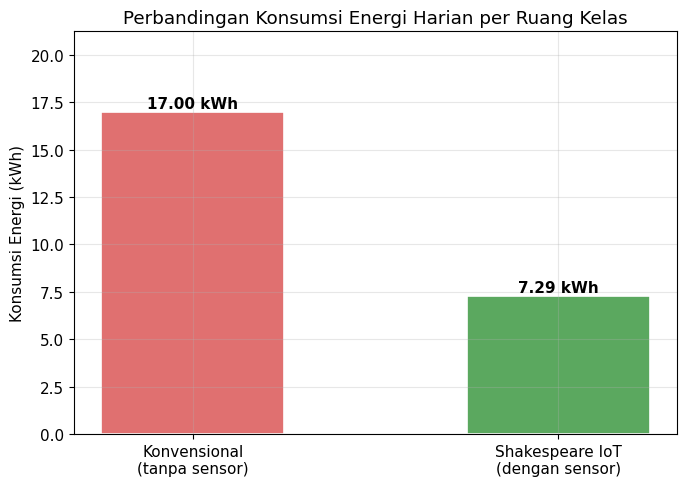

Energi konvensional : 17.00 kWh
Energi dengan IoT   : 7.29 kWh
Penghematan         : 9.71 kWh (57.1%)
Estimasi per bulan  : 213.64 kWh (22 hari kerja)
Estimasi rupiah/bln : Rp 320,460


In [9]:
# Skenario konvensional: AC + lampu menyala penuh selama 10 jam (07.00-17.00)
daya_ac_konvensional   = 1500  # watt
daya_lampu_konvensional = 200  # watt
daya_total_konvensional = daya_ac_konvensional + daya_lampu_konvensional
energi_konvensional     = daya_total_konvensional * 10 / 1000  # kWh

# Skenario IoT: dari simulasi di atas
energi_iot = df['energy_kwh'].iloc[-1]

penghematan_kwh   = energi_konvensional - energi_iot
penghematan_persen = penghematan_kwh / energi_konvensional * 100

# Visualisasi perbandingan
labels  = ['Konvensional\n(tanpa sensor)', 'Shakespeare IoT\n(dengan sensor)']
values  = [energi_konvensional, energi_iot]
colors  = ['#e07070', '#5ba85f']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f} kWh', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Konsumsi Energi (kWh)')
ax.set_title('Perbandingan Konsumsi Energi Harian per Ruang Kelas')
ax.set_ylim(0, energi_konvensional * 1.25)
plt.tight_layout()
plt.show()

print(f"Energi konvensional : {energi_konvensional:.2f} kWh")
print(f"Energi dengan IoT   : {energi_iot:.2f} kWh")
print(f"Penghematan         : {penghematan_kwh:.2f} kWh ({penghematan_persen:.1f}%)")
print(f"Estimasi per bulan  : {penghematan_kwh * 22:.2f} kWh (22 hari kerja)")
print(f"Estimasi rupiah/bln : Rp {penghematan_kwh * 22 * 1500:,.0f}")

## 8. Ekspor Data ke CSV

Data simulasi disimpan ke file CSV agar bisa digunakan untuk keperluan lain seperti pelatihan model atau pelaporan.

In [10]:
df.to_csv('data_simulasi_sensor.csv')
print("Data berhasil disimpan ke data_simulasi_sensor.csv")
print(f"Jumlah baris: {len(df)}, Jumlah kolom: {len(df.columns)}")
print("Kolom:", list(df.columns))

Data berhasil disimpan ke data_simulasi_sensor.csv
Jumlah baris: 600, Jumlah kolom: 12
Kolom: ['occupancy', 'co2_ppm', 'temperature', 'humidity', 'lux', 'lamp_duty', 'voltage_v', 'current_a', 'power_w', 'frequency_hz', 'power_factor', 'energy_kwh']
